# NYUMets: what contrasts does each patient have?

Discovery-first EDA over `data/imaging/.../<patientId>/`. Nothing here assumes the NYUMets
naming convention -- the early cells **report the filename/directory vocabulary they find**,
and the contrast classifier is a small ordered rule table you edit once you have seen it.

Order of business:

0. locate the root, probe the directory layout
1. walk every patient -> file manifest (cached to CSV)
2. token census: what words actually appear in paths / filenames
3. classify files -> contrast labels; **report what did not match**
4. infer visit / session keys (longitudinal structure)
5. availability tables + plots: patient x contrast, session x contrast, co-occurrence, combos
6. header-only scan: shapes, voxel spacing, orientation, within-session affine agreement
7. per-contrast intensity histograms across subjects
8. eyeball one session
9. write the tidy `(patient, session, contrast)` CSV

Steps 0-5 are stdlib + numpy + matplotlib only (no pandas), so they run in a bare env. From step 6
on it also needs `nibabel` and the repo's own `visualization` helpers (`subplot_hists`,
`subplot_images`), which pull in torch.


## 0. Root + layout probe

In [1]:
import os, re, sys, csv, json, time
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# repo root (works whether the kernel cwd is ImMAP/ or ImMAP/notebooks/)
REPO = os.getcwd()
if os.path.basename(REPO) == "notebooks":
    REPO = os.path.dirname(REPO)
if REPO not in sys.path:
    sys.path.insert(0, REPO)

# the symlink lives beside the repo; the gpfs path is the fallback
CANDIDATES = [
    os.path.join(REPO, "..", "datasets", "NYUMets"),
    "/gpfs/data/fenglab/LiFeng/NYUMets/NYUMets",
]
ROOT = next((os.path.abspath(p) for p in CANDIDATES if os.path.isdir(p)), None)
assert ROOT is not None, "none of these exist:\n  " + "\n  ".join(map(os.path.abspath, CANDIDATES))

CACHE = os.path.join(REPO, "cache")
os.makedirs(CACHE, exist_ok=True)
MANIFEST_CSV = os.path.join(CACHE, "nyumets_manifest.csv")
TIDY_CSV     = os.path.join(CACHE, "nyumets_contrasts.csv")

# knobs
MAX_PATIENTS = None    # None = all; set e.g. 50 for a fast first pass over a slow FS
COLLECT_SIZE = True    # st_size per file: one extra stat each, but catches empty/truncated volumes

print("ROOT :", ROOT)
print("real :", os.path.realpath(ROOT))
print("cache:", CACHE)

ROOT : /gpfs/scratch/ee2178/datasets/NYUMets
real : /gpfs/data/fenglab/LiFeng/NYUMets/NYUMets
cache: /gpfs/scratch/ee2178/ImMAP/cache


In [2]:
def tree(root, max_depth=3, max_entries=8, _depth=0, _prefix=""):
    """Depth- and width-limited directory listing. Directories first, files after."""
    try:
        entries = sorted(os.scandir(root), key=lambda e: (not e.is_dir(), e.name))
    except OSError as err:
        print(_prefix + "!! " + str(err))
        return
    shown = entries[:max_entries]
    for e in shown:
        print(_prefix + ("[d] " if e.is_dir() else "    ") + e.name)
        if e.is_dir() and _depth + 1 < max_depth:
            tree(e.path, max_depth, max_entries, _depth + 1, _prefix + "    ")
    if len(entries) > max_entries:
        print(_prefix + f"... (+{len(entries) - max_entries} more)")


print(f"=== {ROOT} ===")
tree(ROOT, max_depth=2, max_entries=12)

=== /gpfs/scratch/ee2178/datasets/NYUMets ===
[d] data
    [d] imaging
        .DS_Store
[d] metadata
        20220804_gkdetails.csv
        20220804_individual.csv
        20220822_traintestsplits.csv
        20220825_imaging.csv
        20220825_timeseries.csv
    .DS_Store


### Where do the patient folders start?

The stated layout is `data/imaging/patientId/<ID>/...`. We try that first and fall back through
the plausible parents. Whatever it picks is printed -- **check it before moving on** and hard-set
`PATIENT_ROOT` if the guess is wrong.

In [3]:
def pick_patient_root(root):
    """First candidate that exists and holds many subdirectories -> the per-patient level."""
    rels = ["data/imaging/patientId", "data/imaging", "data", "imaging", ""]
    best = None
    for rel in rels:
        p = os.path.join(root, *rel.split("/")) if rel else root
        if not os.path.isdir(p):
            continue
        subs = [e.name for e in os.scandir(p) if e.is_dir()]
        print(f"{rel or '.':<24} {len(subs):>6} subdirs   e.g. {sorted(subs)[:4]}")
        if best is None and len(subs) >= 10:
            best = p
    return best


PATIENT_ROOT = pick_patient_root(ROOT)
assert PATIENT_ROOT, "no directory level looked like a patient list -- set PATIENT_ROOT by hand"
print("\nPATIENT_ROOT =", PATIENT_ROOT)

PATIENTS = sorted(e.name for e in os.scandir(PATIENT_ROOT) if e.is_dir())
if MAX_PATIENTS:
    PATIENTS = PATIENTS[:MAX_PATIENTS]
print(f"{len(PATIENTS)} patients   first: {PATIENTS[:5]}   last: {PATIENTS[-3:]}")

data/imaging/patientId     1005 subdirs   e.g. ['10003128', '10030586', '10060943', '10071519']
data/imaging                  1 subdirs   e.g. ['patientId']
data                          1 subdirs   e.g. ['imaging']
.                             2 subdirs   e.g. ['data', 'metadata']

PATIENT_ROOT = /gpfs/scratch/ee2178/datasets/NYUMets/data/imaging/patientId
1005 patients   first: ['10003128', '10030586', '10060943', '10071519', '10071909']   last: ['98552725', '98764381', '99482430']


In [4]:
# what does the inside of a patient folder look like?
for pid in PATIENTS[:3]:
    print(f"=== {pid} ===")
    tree(os.path.join(PATIENT_ROOT, pid), max_depth=3, max_entries=10)
    print()

=== 10003128 ===
[d] studyId
    [d] 1039167733
            CT1.nii
            RTSTRUCT_segmentation.nii
            T2.nii
    [d] 2050762865
            RTSTRUCT_MRI.nii
            RTSTRUCT_segmentation.nii
        .DS_Store
    .DS_Store

=== 10030586 ===
[d] studyId
    [d] 1186096658
            CT1.nii
            FLAIR.nii
            T1.nii
            T2.nii
    [d] 1205703268
            CT1.nii
            FLAIR.nii
            T1.nii
            T2.nii
    [d] 1309924697
            CT1.nii
            FLAIR.nii
            T1.nii
            T2.nii
    [d] 1658635111
            CT1.nii
            FLAIR.nii
            T1.nii
            T2.nii
    [d] 1874507413
            RTSTRUCT_MRI.nii
            RTSTRUCT_segmentation.nii
    [d] 2452757284
            CT1.nii
            FLAIR.nii
            RTSTRUCT_MRI.nii
            RTSTRUCT_segmentation.nii
            T1.nii
            T2.nii
    [d] 3170109256
            CT1.nii
            FLAIR.nii
            T1.nii

## 1. Walk every patient -> manifest

One row per file, `.nii/.nii.gz` and everything else alike -- the non-image files (JSON sidecars,
CSV metadata, DICOM leftovers) tell you as much about the layout as the volumes do.
Cached to CSV; set `REWALK=True` to redo it.

In [5]:
REWALK = False

NII_RE = re.compile(r"\.nii(\.gz)?$", re.I)


def ext_of(fname):
    """'.nii.gz' kept whole; otherwise the last suffix. '' for extensionless files."""
    low = fname.lower()
    if low.endswith(".nii.gz"):
        return ".nii.gz"
    return os.path.splitext(low)[1]


def stem_of(fname):
    e = ext_of(fname)
    return fname[: -len(e)] if e else fname


def walk_patients(patient_root, patients, collect_size=True):
    rows = []
    t0 = time.time()
    for i, pid in enumerate(patients):
        pdir = os.path.join(patient_root, pid)
        for dirpath, _dirnames, filenames in os.walk(pdir):
            rel = os.path.relpath(dirpath, pdir)
            rel = "" if rel == "." else rel.replace(os.sep, "/")
            for fn in filenames:
                nbytes = -1
                if collect_size:
                    try:
                        nbytes = os.stat(os.path.join(dirpath, fn)).st_size
                    except OSError:
                        pass
                rows.append({"patient": pid, "reldir": rel, "fname": fn,
                             "ext": ext_of(fn), "nbytes": nbytes})
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(patients)} patients, {len(rows)} files, {time.time()-t0:.0f}s")
    return rows


FIELDS = ["patient", "reldir", "fname", "ext", "nbytes"]

if REWALK or not os.path.exists(MANIFEST_CSV):
    rows = walk_patients(PATIENT_ROOT, PATIENTS, COLLECT_SIZE)
    with open(MANIFEST_CSV, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=FIELDS)
        w.writeheader()
        w.writerows(rows)
    print("wrote", MANIFEST_CSV)
else:
    with open(MANIFEST_CSV, newline="") as f:
        rows = list(csv.DictReader(f))
    for r in rows:
        r["nbytes"] = int(r["nbytes"])
    print("loaded cache", MANIFEST_CSV)

print(f"{len(rows)} files across {len({r['patient'] for r in rows})} patients")

loaded cache /gpfs/scratch/ee2178/ImMAP/cache/nyumets_manifest.csv
28863 files across 1005 patients


In [6]:
ext_counts = Counter(r["ext"] for r in rows)
print("file extensions:")
for e, n in ext_counts.most_common(20):
    tot = sum(r["nbytes"] for r in rows if r["ext"] == e and r["nbytes"] > 0)
    print(f"  {e or '(none)':<12} {n:>8}   {tot/2**30:>8.2f} GiB")

nii = [r for r in rows if NII_RE.search(r["fname"])]
print(f"\n{len(nii)} NIfTI files")

empty = [r for r in nii if 0 <= r["nbytes"] < 1024]
print(f"{len(empty)} suspiciously small (<1 KiB) NIfTIs"
      + (f", e.g. {[r['fname'] for r in empty[:3]]}" if empty else ""))

depth = Counter(r["reldir"].count("/") + (1 if r["reldir"] else 0) for r in nii)
print("\ndirectory depth below the patient folder (NIfTIs only):")
for d, n in sorted(depth.items()):
    print(f"  depth {d}: {n}")

file extensions:
  .nii            28861     455.44 GiB
  (none)              2       0.00 GiB

28861 NIfTI files
0 suspiciously small (<1 KiB) NIfTIs

directory depth below the patient folder (NIfTIs only):
  depth 2: 28861


## 2. Token census -- the naming vocabulary

This is the cell that actually drives the contrast rules below. It splits every intermediate
directory name and every filename stem into alphanumeric tokens and counts them. Contrast tags,
sequence names, visit markers and derived-file suffixes all fall out here.

In [7]:
TOKEN_RE = re.compile(r"[^a-z0-9]+")

def toks(s):
    return [t for t in TOKEN_RE.split(str(s).lower()) if t]

def mask(s):
    """Collapse digit runs: '20190505' -> '#', 'NYU0042' -> 'NYU#'. Dates and patient IDs
    otherwise swamp every count and hide the handful of tokens that carry meaning."""
    return re.sub(r"\d+", "#", str(s))


dir_parts  = [p for r in nii for p in r["reldir"].split("/") if p]
file_stems = [stem_of(r["fname"]) for r in nii]

def show(counter, title, n=40):
    print(f"--- {title} ({len(counter)} distinct) ---")
    if not counter:
        print("  (none)")
    for t, c in counter.most_common(n):
        print(f"  {t:<24} {c}")
    print()

show(Counter(t for p in dir_parts  for t in toks(mask(p))), "directory-name tokens (masked)")
show(Counter(t for s in file_stems for t in toks(mask(s))), "filename tokens (masked)")

# short bare numbers survive masking as a category of their own -- echo index, series number,
# b-value. Long ones are dates/IDs and are already covered by the masked counts above.
show(Counter(t for s in file_stems for t in toks(s) if t.isdigit() and len(t) <= 4),
     "short numeric filename tokens (<=4 digits, unmasked)", n=20)

--- directory-name tokens (masked) (1 distinct) ---
  studyid                  28861

--- filename tokens (masked) (8 distinct) ---
  t                        12462
  ct                       7245
  flair                    5322
  rtstruct                 3828
  segmentation             2370
  mri                      1462
  po                       4
  filt                     3

--- short numeric filename tokens (<=4 digits, unmasked) (0 distinct) ---
  (none)



In [8]:
# full directory names and full filenames -- tokens alone can hide the real convention
print("--- distinct reldir shapes, digit runs masked (top 25) ---")
for d, c in Counter(mask(r["reldir"]) for r in nii).most_common(25):
    print(f"  {c:>7}  {d or '(patient root)'}")

print("\n--- distinct filenames, digit runs masked (top 40) ---")
for f_, c in Counter(mask(r["fname"]) for r in nii).most_common(40):
    print(f"  {c:>7}  {f_}")

--- distinct reldir shapes, digit runs masked (top 25) ---
    28861  studyId/#

--- distinct filenames, digit runs masked (top 40) ---
    12462  T#.nii
     7245  CT#.nii
     5322  FLAIR.nii
     2363  RTSTRUCT_segmentation.nii
     1462  RTSTRUCT_MRI.nii
        4  PO_segmentation.nii
        3  RTSTRUCT_segmentation_filt.nii


## 3. Classify files -> contrast labels

Ordered rules, **first match wins**, applied to `reldir + "/" + filename` lowercased. Order is
load-bearing: `seg` before everything (a `*_t1c_seg` is a label, not an image), `FLAIR` before
`T2` (`t2_flair` is FLAIR), `T1ce` before `T1`, `ADC` before `DWI`.

Every rule that matches is recorded, not just the winner, so rule collisions show up as
`ambiguous` rather than silently resolving. **Edit this table after reading section 2**, then
re-run from here -- nothing above depends on it.

In [9]:
CONTRAST_RULES = [
    # (label, regex over the lowercased "reldir/filename")
    ("seg",   r"(seg|label|lesion|mask|tumou?r|gtv|_roi|annotation|contour)"),
    ("ADC",   r"(adc|apparent[\W_]?diff)"),
    ("DWI",   r"(dwi|dti|trace|b1000|diffusion)"),
    ("SWI",   r"(swi|gre\b|t2star|t2\*|susceptib|medic)"),
    ("FLAIR", r"(flair|dark[\W_]?fluid)"),
    # NYUMets writes the contrast-enhanced T1 as CT1 -- the modifier PRECEDES the t1, which the
    # usual "t1 + suffix" patterns all miss. Without the leading-c alternative these files fall
    # through to the T1 rule (t1 is a substring of ct1) and silently pollute the T1 bucket.
    # The guard must be a lookbehind, NOT \bct1\b: '_' is a word character, so \b never fires
    # between the '_' and the 'c' in 'NYU0001_CT1.nii.gz'. (?!\d) keeps CT10 out.
    ("T1ce",  r"((?<![a-z0-9])c[\W_]?t1(?!\d)|"
              r"t1[\W_]*(ce|c\b|post|gd|gad|contrast)|post[\W_]?contrast|"
              r"(mprage|bravo|spgr|tfe)[\W_]*(post|gd|c\b)|t1[\W_]?w?[\W_]?gd)"),
    ("T1",    r"(t1|mprage|bravo|spgr|tfe|mp[\W_]?rage)"),
    ("T2",    r"(t2|tse|cube|space)"),
]
CONTRAST_RES = [(lab, re.compile(pat, re.I)) for lab, pat in CONTRAST_RULES]
LABELS = [lab for lab, _ in CONTRAST_RULES]


def classify(reldir, fname):
    """-> (winning label or None, tuple of every label whose rule matched)."""
    s = (reldir + "/" + fname).lower()
    hits = tuple(lab for lab, rx in CONTRAST_RES if rx.search(s))
    return (hits[0] if hits else None), hits


for r in nii:
    r["contrast"], r["hits"] = classify(r["reldir"], r["fname"])

print("classified:")
for lab, n in Counter(r["contrast"] for r in nii).most_common():
    print(f"  {str(lab):<8} {n:>7}")

amb = [r for r in nii if len(r["hits"]) > 1]
print(f"\n{len(amb)} files matched >1 rule (winner = first). Collision patterns:")
for combo, n in Counter(r["hits"] for r in amb).most_common(15):
    ex = next(r["fname"] for r in amb if r["hits"] == combo)
    print(f"  {n:>7}  {' > '.join(combo):<28} e.g. {ex}")

classified:
  T1ce        7245
  T2          6920
  T1          5542
  FLAIR       5322
  seg         2370
  None        1462

7245 files matched >1 rule (winner = first). Collision patterns:
     7245  T1ce > T1                    e.g. CT1.nii


In [10]:
# --- the diagnostic that matters: what did NOT match any rule ---
un = [r for r in nii if r["contrast"] is None]
print(f"{len(un)} unclassified NIfTIs ({100*len(un)/max(len(nii),1):.1f}%)\n")

print("--- unclassified filenames, digit runs masked (top 40) ---")
for f_, c in Counter(mask(r["fname"]) for r in un).most_common(40):
    print(f"  {c:>7}  {f_}")

print("\n--- tokens in unclassified files, masked (top 30) ---")
for t, c in Counter(t for r in un for t in toks(mask(stem_of(r["fname"])))).most_common(30):
    print(f"  {t:<22} {c}")

print("\n--- and their parent directories, masked (top 15) ---")
for d, c in Counter(mask(r["reldir"]) for r in un).most_common(15):
    print(f"  {c:>7}  {d or '(patient root)'}")

1462 unclassified NIfTIs (5.1%)

--- unclassified filenames, digit runs masked (top 40) ---
     1462  RTSTRUCT_MRI.nii

--- tokens in unclassified files, masked (top 30) ---
  rtstruct               1462
  mri                    1462

--- and their parent directories, masked (top 15) ---
     1462  studyId/#


## 4. Visit / session keys

NYUMets is longitudinal, so "which contrasts does patient X have" is really
"which contrasts does patient X have *at visit V*". We look for a session key in this order:
an ISO-ish or 8-digit date anywhere in the path, then a `ses/visit/scan/study/tp` marker, then
the first directory component below the patient folder, then `(single)` for a flat layout.

If the keys come out as dates they sort chronologically and visit ordinals are meaningful;
if not, the ordinal is just a stable arbitrary index. The cell says which case you are in.

In [11]:
DATE_RE = re.compile(r"((?:19|20)\d{2})[-_.]?(\d{2})[-_.]?(\d{2})")
SESS_RE = re.compile(r"\b(?:ses|session|visit|scan|study|timepoint|tp)[-_ ]?(\d+)\b", re.I)


def session_key(reldir, fname):
    for src in (reldir, fname):
        m = DATE_RE.search(src)
        if m:
            return "-".join(m.groups()), "date"
    for src in (reldir, fname):
        m = SESS_RE.search(src)
        if m:
            return "ses%03d" % int(m.group(1)), "marker"
    if reldir:
        return reldir.split("/")[0], "dirname"
    return "(single)", "flat"


for r in nii:
    r["session"], r["session_src"] = session_key(r["reldir"], r["fname"])

print("session key source:", dict(Counter(r["session_src"] for r in nii)))

sess_by_pat = defaultdict(set)
for r in nii:
    sess_by_pat[r["patient"]].add(r["session"])

counts = [len(v) for v in sess_by_pat.values()]
nsess = Counter(counts)
print(f"\nsessions per patient: min {min(counts)}, max {max(counts)}, mean {np.mean(counts):.2f}")
for k in sorted(nsess)[:15]:
    print(f"  {k:>3} session(s): {nsess[k]:>5} patients")

ex = max(sess_by_pat, key=lambda p: len(sess_by_pat[p]))
print(f"\nmost visits: {ex} -> {sorted(sess_by_pat[ex])[:12]}")

session key source: {'dirname': 25821, 'date': 3040}

sessions per patient: min 1, max 9, mean 1.84
    1 session(s):   492 patients
    2 session(s):   303 patients
    3 session(s):   139 patients
    4 session(s):    49 patients
    5 session(s):    11 patients
    6 session(s):     3 patients
    7 session(s):     5 patients
    8 session(s):     1 patients
    9 session(s):     2 patients

most visits: 29590903 -> ['1928-14-32', '1930-91-50', '1988-73-08', '2021-09-70', '2039-91-72', '2074-74-10', '2085-61-34', '2088-60-36', 'studyId']


## 5. Availability

In [12]:
# (patient, session) -> {contrast: [files]}
cell = defaultdict(lambda: defaultdict(list))
for r in nii:
    if r["contrast"]:
        cell[(r["patient"], r["session"])][r["contrast"]].append(r)

pat_contrasts = defaultdict(set)          # pooled over all visits
for (p, s), d in cell.items():
    pat_contrasts[p] |= set(d)

n_pat  = len(PATIENTS)
n_sess = len(cell)
print(f"{n_pat} patients, {n_sess} (patient, session) cells\n")

print(f"{'contrast':<8} {'patients':>10} {'%':>6}   {'sessions':>10} {'%':>6}")
for lab in LABELS:
    np_ = sum(lab in v for v in pat_contrasts.values())
    ns_ = sum(lab in d for d in cell.values())
    print(f"{lab:<8} {np_:>10} {100*np_/max(n_pat,1):>5.1f}%   "
          f"{ns_:>10} {100*ns_/max(n_sess,1):>5.1f}%")

dupes = [(k, lab, len(v)) for k, d in cell.items() for lab, v in d.items() if len(v) > 1]
print(f"\n{len(dupes)} (patient, session, contrast) cells hold >1 file "
      "(repeat acquisitions, echoes, or an over-broad rule)")
for k, lab, n in dupes[:8]:
    print(f"  {k} {lab} x{n}: {[r['fname'] for r in cell[k][lab]][:3]}")

1005 patients, 1845 (patient, session) cells

contrast   patients      %     sessions      %
seg             907  90.2%         1125  61.0%
ADC               0   0.0%            0   0.0%
DWI               0   0.0%            0   0.0%
SWI               0   0.0%            0   0.0%
FLAIR           877  87.3%         1436  77.8%
T1ce            998  99.3%         1738  94.2%
T1              873  86.9%         1457  79.0%
T2             1000  99.5%         1714  92.9%

3717 (patient, session, contrast) cells hold >1 file (repeat acquisitions, echoes, or an over-broad rule)
  ('10030586', 'studyId') T2 x6: ['T2.nii', 'T2.nii', 'T2.nii']
  ('10030586', 'studyId') T1 x5: ['T1.nii', 'T1.nii', 'T1.nii']
  ('10030586', 'studyId') T1ce x6: ['CT1.nii', 'CT1.nii', 'CT1.nii']
  ('10030586', 'studyId') FLAIR x5: ['FLAIR.nii', 'FLAIR.nii', 'FLAIR.nii']
  ('10030586', 'studyId') seg x3: ['RTSTRUCT_segmentation.nii', 'RTSTRUCT_segmentation.nii', 'RTSTRUCT_segmentation.nii']
  ('10060943', 'studyId') seg

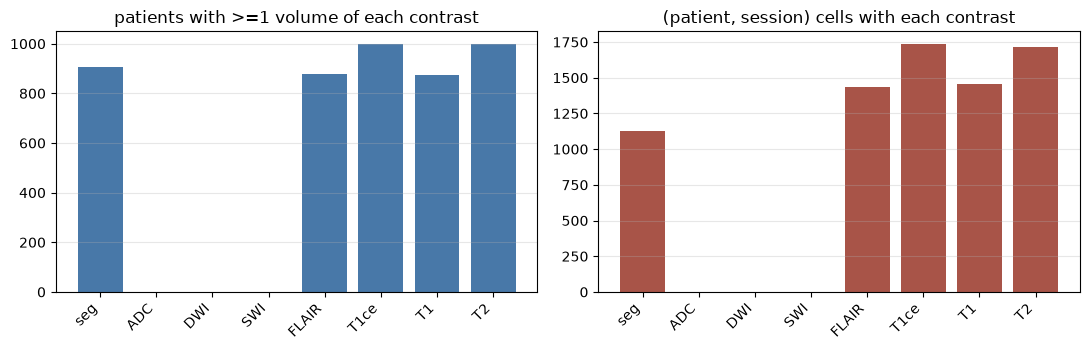

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
xs = np.arange(len(LABELS))

axes[0].bar(xs, [sum(l in v for v in pat_contrasts.values()) for l in LABELS], color="#4878a8")
axes[0].set_title("patients with >=1 volume of each contrast")
axes[1].bar(xs, [sum(l in d for d in cell.values()) for l in LABELS], color="#a85448")
axes[1].set_title("(patient, session) cells with each contrast")
for ax in axes:
    ax.set_xticks(xs); ax.set_xticklabels(LABELS, rotation=45, ha="right")
    ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

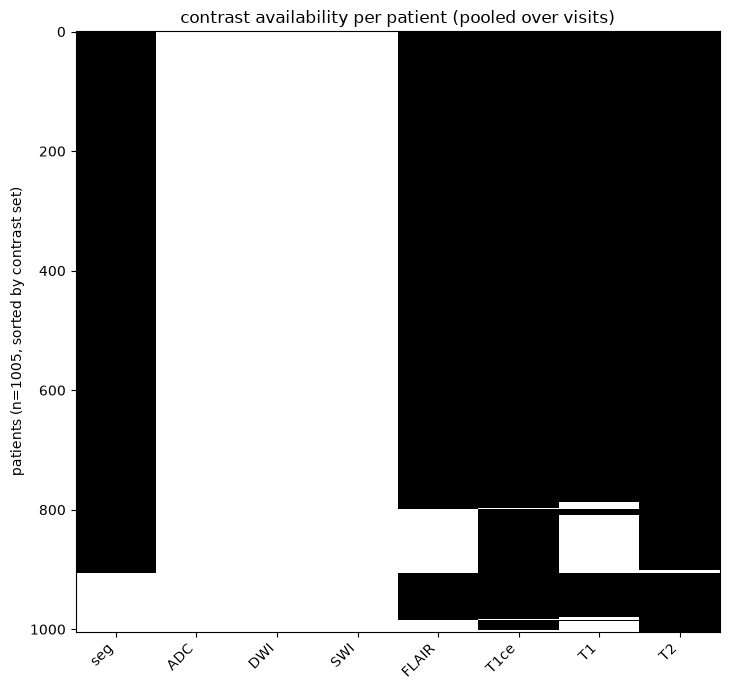

In [14]:
# binary availability heatmap, patients grouped by which set they have
order = sorted(pat_contrasts, key=lambda p: (tuple(l in pat_contrasts[p] for l in LABELS), p),
               reverse=True)
A = np.array([[l in pat_contrasts[p] for l in LABELS] for p in order], dtype=float)

fig, ax = plt.subplots(figsize=(0.55 * len(LABELS) + 3, 7))
ax.imshow(A, aspect="auto", cmap="Greys", interpolation="nearest", vmin=0, vmax=1)
ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, rotation=45, ha="right")
ax.set_ylabel(f"patients (n={len(order)}, sorted by contrast set)")
ax.set_title("contrast availability per patient (pooled over visits)")
plt.tight_layout(); plt.show()

In [15]:
# which contrast SETS occur, at the session level
combos = Counter(frozenset(d) for d in cell.values())
print(f"{len(combos)} distinct contrast sets over {n_sess} sessions\n")
print(f"{'n':>7}  {'%':>6}  set")
for cset, n in combos.most_common(20):
    print(f"{n:>7}  {100*n/n_sess:>5.1f}%  {sorted(cset, key=LABELS.index)}")

27 distinct contrast sets over 1845 sessions

      n       %  set
    820   44.4%  ['seg', 'FLAIR', 'T1ce', 'T1', 'T2']
    527   28.6%  ['FLAIR', 'T1ce', 'T1', 'T2']
    182    9.9%  ['seg', 'T1ce', 'T2']
     75    4.1%  ['T1ce', 'T2']
     66    3.6%  ['seg']
     34    1.8%  ['T1ce', 'T1', 'T2']
     27    1.5%  ['FLAIR', 'T1ce', 'T1']
     16    0.9%  ['seg', 'T1ce', 'T1', 'T2']
     16    0.9%  ['FLAIR', 'T1ce', 'T2']
     11    0.6%  ['seg', 'FLAIR', 'T1ce', 'T1']
     11    0.6%  ['FLAIR', 'T2']
     10    0.5%  ['seg', 'FLAIR', 'T1ce', 'T2']
      7    0.4%  ['seg', 'T2']
      7    0.4%  ['T1ce', 'T1']
      6    0.3%  ['FLAIR', 'T1', 'T2']
      6    0.3%  ['seg', 'T1ce']
      5    0.3%  ['T2']
      4    0.2%  ['T1ce']
      3    0.2%  ['seg', 'FLAIR', 'T2']
      2    0.1%  ['T1', 'T2']


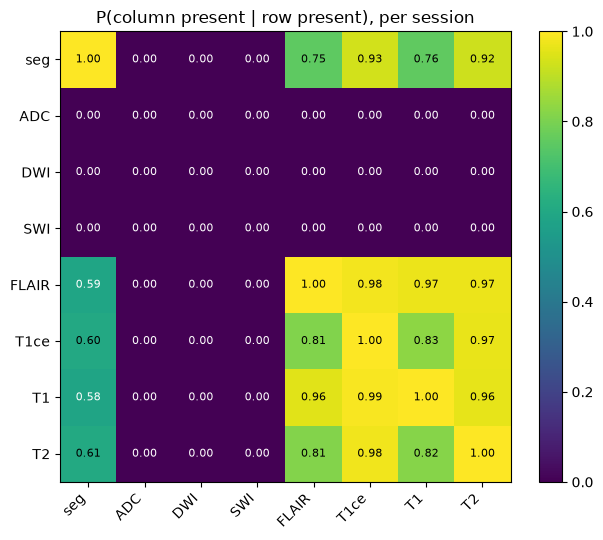

In [16]:
# co-occurrence at the session level: P(col | row)
M = np.zeros((len(LABELS), len(LABELS)))
for d in cell.values():
    present = [i for i, l in enumerate(LABELS) if l in d]
    for i in present:
        for j in present:
            M[i, j] += 1
P = M / np.maximum(np.diag(M), 1)[:, None]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(P, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, rotation=45, ha="right")
ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS)
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        ax.text(j, i, f"{P[i,j]:.2f}", ha="center", va="center",
                color="w" if P[i, j] < .6 else "k", fontsize=8)
ax.set_title("P(column present | row present), per session")
fig.colorbar(im, ax=ax, fraction=.046); plt.tight_layout(); plt.show()

### The query that actually gates the synthesis work

How much of this dataset is usable as BraTS-style multi-contrast input, i.e. how many
**visits** carry the full quartet at once (and how many patients have at least one such visit).
Change `CORE` to test other requirements -- e.g. `("T1", "T1ce")` for a bare T1 -> T1ce bridge.

In [17]:
CORE = ("FLAIR", "T1", "T1ce", "T2")

full_sess = [k for k, d in cell.items() if all(l in d for l in CORE)]
full_pats = {p for p, _ in full_sess}
print(f"CORE = {CORE}")
print(f"  {len(full_sess)}/{n_sess} sessions ({100*len(full_sess)/max(n_sess,1):.1f}%) complete")
print(f"  {len(full_pats)}/{n_pat} patients ({100*len(full_pats)/max(n_pat,1):.1f}%) "
      "have >=1 complete visit")

per_pat = Counter(p for p, _ in full_sess)
print(f"\ncomplete visits per patient (of those that have any): "
      f"max {max(per_pat.values()) if per_pat else 0}")
for k, v in sorted(Counter(per_pat.values()).items())[:12]:
    print(f"  {k:>3} complete visit(s): {v:>5} patients")

print("\nmissing-contrast breakdown over incomplete sessions:")
inc = [d for k, d in cell.items() if not all(l in d for l in CORE)]
for lab, c in Counter(l for d in inc for l in CORE if l not in d).most_common():
    print(f"  missing {lab:<6} {c:>7}  ({100*c/max(len(inc),1):.1f}% of incomplete)")

CORE = ('FLAIR', 'T1', 'T1ce', 'T2')
  1347/1845 sessions (73.0%) complete
  858/1005 patients (85.4%) have >=1 complete visit

complete visits per patient (of those that have any): max 8
    1 complete visit(s):   539 patients
    2 complete visit(s):   202 patients
    3 complete visit(s):    82 patients
    4 complete visit(s):    25 patients
    5 complete visit(s):     6 patients
    6 complete visit(s):     1 patients
    7 complete visit(s):     2 patients
    8 complete visit(s):     1 patients

missing-contrast breakdown over incomplete sessions:
  missing FLAIR      409  (82.1% of incomplete)
  missing T1         388  (77.9% of incomplete)
  missing T2         131  (26.3% of incomplete)
  missing T1ce       107  (21.5% of incomplete)


## 6. Header-only scan: geometry

`nib.load` is lazy -- the header comes back without touching the voxel data, so this is cheap
even over gpfs. Two things we need to know before any of this is trainable:

* is every volume on a **common grid** (already resampled / skull-stripped like BraTS), or raw
  scanner geometry with per-sequence spacing?
* within one visit, do the contrasts share an affine, i.e. are they **co-registered**?

In [18]:
import nibabel as nib

HDR_SAMPLE = 150        # files per contrast

def header_info(path):
    img = nib.load(path)                     # lazy: no voxel data read
    hdr = img.header
    return {"shape": tuple(int(s) for s in img.shape[:3]),
            "zooms": tuple(round(float(z), 2) for z in hdr.get_zooms()[:3]),
            "axcodes": "".join(nib.aff2axcodes(img.affine)),
            "dtype": str(hdr.get_data_dtype())}


def full_path(r):
    return os.path.join(PATIENT_ROOT, r["patient"], r["reldir"], r["fname"])


rng = np.random.default_rng(0)
for lab in LABELS:
    pool = [r for r in nii if r["contrast"] == lab]
    if not pool:
        continue
    sel = [pool[i] for i in rng.permutation(len(pool))[:HDR_SAMPLE]]
    infos, bad = [], 0
    for r in sel:
        try:
            infos.append(header_info(full_path(r)))
        except Exception:
            bad += 1
    if not infos:
        print(f"{lab}: {bad} read failures\n"); continue
    print(f"--- {lab}  (n={len(infos)} sampled of {len(pool)}"
          + (f", {bad} unreadable" if bad else "") + ") ---")
    for key in ("shape", "zooms", "axcodes", "dtype"):
        top = Counter(i[key] for i in infos).most_common(4)
        print(f"  {key:<8} " + "  |  ".join(f"{v} x{c}" for v, c in top))
    print()

--- seg  (n=150 sampled of 2370) ---
  shape    (210, 210, 208) x33  |  (220, 220, 160) x10  |  (220, 220, 170) x9  |  (220, 220, 150) x9
  zooms    (1.0, 1.0, 1.0) x118  |  (0.82, 0.82, 1.0) x32
  axcodes  RAS x150
  dtype    uint16 x61  |  float32 x55  |  float64 x34

--- FLAIR  (n=150 sampled of 5322) ---
  shape    (220, 220, 150) x25  |  (220, 220, 160) x25  |  (220, 220, 170) x13  |  (179, 220, 160) x9
  zooms    (1.0, 1.0, 1.0) x150
  axcodes  RAS x150
  dtype    int16 x150

--- T1ce  (n=150 sampled of 7245) ---
  shape    (220, 220, 160) x33  |  (210, 210, 208) x23  |  (220, 220, 150) x17  |  (220, 220, 170) x12
  zooms    (1.0, 1.0, 1.0) x150
  axcodes  RAS x150
  dtype    int16 x150

--- T1  (n=150 sampled of 5542) ---
  shape    (220, 220, 160) x33  |  (220, 220, 150) x26  |  (220, 220, 170) x14  |  (186, 220, 160) x8
  zooms    (1.0, 1.0, 1.0) x150
  axcodes  RAS x150
  dtype    int16 x150

--- T2  (n=150 sampled of 6920) ---
  shape    (220, 220, 160) x33  |  (210, 210, 20

In [19]:
# co-registration check: within a session, do contrasts share shape + affine?
SESS_SAMPLE = 60

keys = [k for k, d in cell.items() if len(d) >= 2]
sel = [keys[i] for i in rng.permutation(len(keys))[:SESS_SAMPLE]]

same_shape = same_affine = total = 0
for k in sel:
    firsts = [v[0] for v in cell[k].values()]
    try:
        imgs = [nib.load(full_path(r)) for r in firsts]
    except Exception:
        continue
    total += 1
    shapes = {tuple(int(s) for s in im.shape[:3]) for im in imgs}
    same_shape += len(shapes) == 1
    a0 = imgs[0].affine
    same_affine += all(np.allclose(im.affine, a0, atol=1e-3) for im in imgs)

print(f"sampled {total} multi-contrast sessions")
print(f"  identical shape  across contrasts: {same_shape}/{total}")
print(f"  identical affine across contrasts: {same_affine}/{total}")
print("\nidentical affine => already co-registered onto a common grid (BraTS-like).")
print("shapes agree but affines do not => same matrix size, different scanner geometry.")
print("neither => registration + resampling is a required preprocessing step.")

sampled 60 multi-contrast sessions
  identical shape  across contrasts: 32/60
  identical affine across contrasts: 37/60

identical affine => already co-registered onto a common grid (BraTS-like).
shapes agree but affines do not => same matrix size, different scanner geometry.
neither => registration + resampling is a required preprocessing step.


## 7. Intensity distributions per contrast

Whether the volumes share an intensity scale decides how much normalization the pipeline owes
this data. `subplot_hists` handles the four things that make these comparable -- foreground
masking, a percentile range instead of the full tail, one set of bin edges per panel, and density
rather than count -- so this cell only has to choose the voxels.

In [20]:
from visualization import subplot_hists, subplot_images

N_SUBJECTS     = 6           # sessions to overlay
HIST_CONTRASTS = [l for l in LABELS if l != "seg"]
MAX_VOXELS     = 200_000     # cap per volume, so 6 x 7 volumes stay in memory
BG_FRAC        = 0.05        # drop voxels below BG_FRAC * p99.5 -- air and the noise floor
BINS           = 120

_rng_h = np.random.default_rng(0)


def fg_samples(path, max_voxels=MAX_VOXELS, bg_frac=BG_FRAC):
    """Foreground voxel samples from one volume.

    NYUMets is not necessarily skull-stripped, so air is a low-but-nonzero noise floor rather
    than exact zeros -- `mask=` has nothing to key on and a plain `> 0` keeps all of it.
    Thresholding relative to the volume's own robust max drops it without a brain extractor.
    Set bg_frac=0 if the data turns out to be stripped after all.
    """
    v = np.asanyarray(nib.load(path).dataobj)
    while v.ndim > 3:                      # 4D (echoes / b-values) -> first volume
        v = v[..., 0]
    v = v.astype(np.float32).ravel()
    v = v[np.isfinite(v)]
    if v.size == 0:
        return v
    v = v[v > bg_frac * np.percentile(v, 99.5)]
    if v.size > max_voxels:
        v = v[_rng_h.choice(v.size, max_voxels, replace=False)]
    return v


# sessions with the most contrasts, so the same subjects appear in as many panels as possible
pool = full_sess if full_sess else sorted(cell, key=lambda k: -len(cell[k]))
keys = pool[:N_SUBJECTS]

samples = {lab: {} for lab in HIST_CONTRASTS}
for k in keys:
    for lab in HIST_CONTRASTS:
        if lab not in cell[k]:
            continue
        try:
            s = fg_samples(full_path(cell[k][lab][0]))
        except Exception as err:
            print(f"  !! {k} {lab}: {err}")
            continue
        if s.size:
            samples[lab][k] = s

present = [l for l in HIST_CONTRASTS if samples[l]]
print(f"{len(keys)} sessions, contrasts with data: {present}")

6 sessions, contrasts with data: ['FLAIR', 'T1ce', 'T1', 'T2']


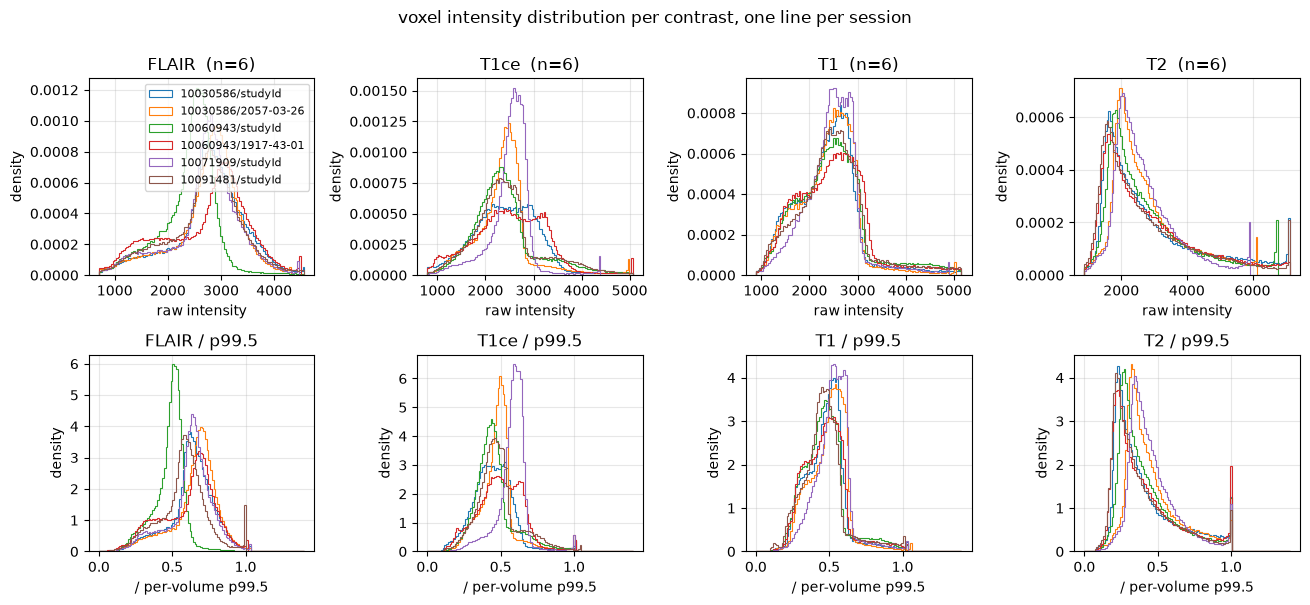

(<Figure size 1320x600 with 8 Axes>,
 array([<Axes: title={'center': 'FLAIR  (n=6)'}, xlabel='raw intensity', ylabel='density'>,
        <Axes: title={'center': 'T1ce  (n=6)'}, xlabel='raw intensity', ylabel='density'>,
        <Axes: title={'center': 'T1  (n=6)'}, xlabel='raw intensity', ylabel='density'>,
        <Axes: title={'center': 'T2  (n=6)'}, xlabel='raw intensity', ylabel='density'>,
        <Axes: title={'center': 'FLAIR / p99.5'}, xlabel='/ per-volume p99.5', ylabel='density'>,
        <Axes: title={'center': 'T1ce / p99.5'}, xlabel='/ per-volume p99.5', ylabel='density'>,
        <Axes: title={'center': 'T1 / p99.5'}, xlabel='/ per-volume p99.5', ylabel='density'>,
        <Axes: title={'center': 'T2 / p99.5'}, xlabel='/ per-volume p99.5', ylabel='density'>],
       dtype=object))

In [21]:
# Top row raw, bottom row divided by each volume's own p99.5. Panels are NOT share_bins --
# contrasts live on different scales and should not be forced onto one axis; within a panel
# plot_hist already pools the series to one set of edges, which is the comparison that matters.
N = len(present)
lab_of = lambda k: f"{k[0]}/{k[1]}"

panels  = [{lab_of(k): v for k, v in samples[l].items()} for l in present]
panels += [{lab_of(k): v / np.percentile(v, 99.5) for k, v in samples[l].items()}
           for l in present]

# plot_hist passes color=None straight to ax.hist, and an EXPLICIT None disables matplotlib's
# property cycle -- every step-histogram then draws black and the legend is useless. So name the
# colours. As a TUPLE, not a list: subplot_hists spreads any *list* whose length matches the
# panel count across the panels, which would silently fire when len(keys) == 2*len(present).
_cyc = plt.rcParams["axes.prop_cycle"].by_key()["color"]
colors = tuple(_cyc[i % len(_cyc)] for i in range(len(keys)))

subplot_hists(
    panels,
    ncols=N,
    titles=[f"{l}  (n={len(samples[l])})" for l in present] + [f"{l} / p99.5" for l in present],
    bins=BINS,
    p=(0.5, 99.5),                                   # raw row: percentile range per panel
    range=[None] * N + [(0.0, 1.4)] * N,             # normalised row: one fixed range
    color=colors,
    xlabel=["raw intensity"] * N + ["/ per-volume p99.5"] * N,
    legend=[True] + [False] * (2 * N - 1),           # one legend is enough for the figure
    panel_size=(3.3, 3.0),
    suptitle="voxel intensity distribution per contrast, one line per session",
)

In [22]:
# --- the number that decides whether per-subject normalisation is mandatory ---
print(f"{'contrast':<8} {'n':>3} {'med p50':>10} {'med p95':>10} {'med p99.5':>11} "
      f"{'p99.5 max/min':>14}")
for lab in present:
    q = np.array([np.percentile(v, [50, 95, 99.5]) for v in samples[lab].values()])
    spread = q[:, 2].max() / max(q[:, 2].min(), 1e-9)
    print(f"{lab:<8} {len(q):>3} {np.median(q[:,0]):>10.1f} {np.median(q[:,1]):>10.1f} "
          f"{np.median(q[:,2]):>11.1f} {spread:>14.2f}")

print("\np99.5 max/min ~1 => volumes already share a scale; >>1 => per-subject normalisation")
print("is required before any additive/percentile contrast model. If the bottom-row curves")
print("superimpose, dividing by p99.5 is sufficient; if they do not, the tail is being set by")
print("pathology rather than normal tissue and a lower percentile is needed.")
print("\nADC is a quantitative map in physical units, so its spread should be ~1.0 even when")
print("the weighted contrasts scatter. If it is not, suspect the ADC files, not the scaling.")

contrast   n    med p50    med p95   med p99.5  p99.5 max/min
FLAIR      6     2798.0     3722.5      4425.5           1.20
T1ce       6     2411.0     3571.0      5058.0           1.26
T1         6     2451.5     3759.5      5118.0           1.14
T2         6     2437.0     5808.5      6918.0           1.24

p99.5 max/min ~1 => volumes already share a scale; >>1 => per-subject normalisation
is required before any additive/percentile contrast model. If the bottom-row curves
superimpose, dividing by p99.5 is sufficient; if they do not, the tail is being set by
pathology rather than normal tissue and a lower percentile is needed.

ADC is a quantitative map in physical units, so its spread should be ~1.0 even when
the weighted contrasts scatter. If it is not, suspect the ADC files, not the scaling.


## 8. Eyeball one complete visit

showing ('10030586', 'studyId') -> ['seg', 'FLAIR', 'T1ce', 'T1', 'T2']


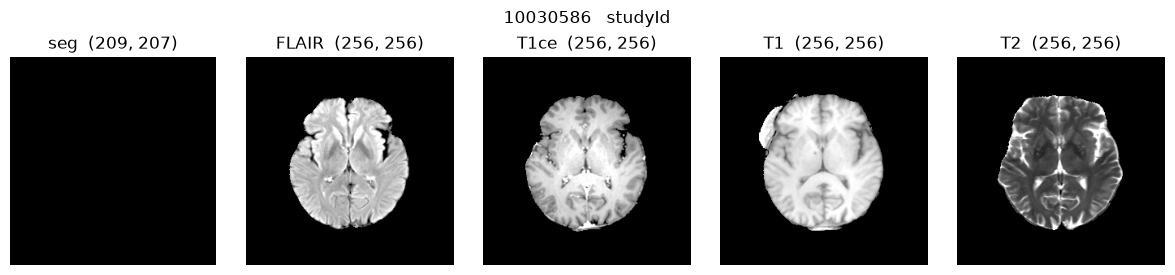

(<Figure size 1200x270 with 5 Axes>,
 array([[<Axes: title={'center': 'seg  (209, 207)'}>,
         <Axes: title={'center': 'FLAIR  (256, 256)'}>,
         <Axes: title={'center': 'T1ce  (256, 256)'}>,
         <Axes: title={'center': 'T1  (256, 256)'}>,
         <Axes: title={'center': 'T2  (256, 256)'}>]], dtype=object))

In [23]:
def mid_slice(path):
    """Middle axial slice of a volume, canonicalised to RAS so orientation is comparable."""
    img = nib.as_closest_canonical(nib.load(path))
    vol = np.asanyarray(img.dataobj)
    while vol.ndim > 3:
        vol = vol[..., 0]
    z = vol.shape[2] // 2
    return np.rot90(vol[:, :, z].astype(np.float32))


key = full_sess[0] if full_sess else max(cell, key=lambda k: len(cell[k]))
d = cell[key]
labs = sorted(d, key=LABELS.index)
print("showing", key, "->", labs)

imgs = [mid_slice(full_path(d[lab][0])) for lab in labs]

# share_window=False is the point: each contrast gets its own percentile stretch. The default
# shared window would scale every panel to whichever contrast has the largest dynamic range and
# black out the rest -- exactly what section 7's raw row shows happening.
subplot_images(
    imgs,
    titles=[f"{lab}  {im.shape}" for lab, im in zip(labs, imgs)],
    p=(1, 99),
    share_window=False,
    suptitle=f"{key[0]}   {key[1]}",
)

## 9. Tidy CSV

One row per `(patient, session, contrast, file)` with the path relative to `PATIENT_ROOT`.
This is what a `datasets/NYUMets/` registrar should read later, so it does not have to
re-derive any of the above.

In [24]:
sess_order = {}
for p, ss in sess_by_pat.items():
    for i, s in enumerate(sorted(ss)):
        sess_order[(p, s)] = i

out = []
for (p, s), d in sorted(cell.items()):
    for lab in sorted(d, key=LABELS.index):
        for r in d[lab]:
            out.append({"patient": p, "session": s, "visit_idx": sess_order[(p, s)],
                        "contrast": lab, "n_at_cell": len(d[lab]),
                        "relpath": "/".join(x for x in (p, r["reldir"], r["fname"]) if x),
                        "nbytes": r["nbytes"]})

cols = ["patient", "session", "visit_idx", "contrast", "n_at_cell", "relpath", "nbytes"]
with open(TIDY_CSV, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=cols)
    w.writeheader(); w.writerows(out)

print(f"wrote {len(out)} rows -> {TIDY_CSV}")
print("root for relpath:", PATIENT_ROOT)
for r in out[:5]:
    print(" ", r)

wrote 27399 rows -> /gpfs/scratch/ee2178/ImMAP/cache/nyumets_contrasts.csv
root for relpath: /gpfs/scratch/ee2178/datasets/NYUMets/data/imaging/patientId
  {'patient': '10003128', 'session': '2050-76-28', 'visit_idx': 0, 'contrast': 'seg', 'n_at_cell': 1, 'relpath': '10003128/studyId/2050762865/RTSTRUCT_segmentation.nii', 'nbytes': 73382752}
  {'patient': '10003128', 'session': 'studyId', 'visit_idx': 1, 'contrast': 'seg', 'n_at_cell': 1, 'relpath': '10003128/studyId/1039167733/RTSTRUCT_segmentation.nii', 'nbytes': 17046368}
  {'patient': '10003128', 'session': 'studyId', 'visit_idx': 1, 'contrast': 'T1ce', 'n_at_cell': 1, 'relpath': '10003128/studyId/1039167733/CT1.nii', 'nbytes': 18348480}
  {'patient': '10003128', 'session': 'studyId', 'visit_idx': 1, 'contrast': 'T2', 'n_at_cell': 1, 'relpath': '10003128/studyId/1039167733/T2.nii', 'nbytes': 18348480}
  {'patient': '10030586', 'session': '2057-03-26', 'visit_idx': 0, 'contrast': 'FLAIR', 'n_at_cell': 1, 'relpath': '10030586/studyId

9 panels; difference window +/-2620 (p99.0 of |CT1 - T1|)


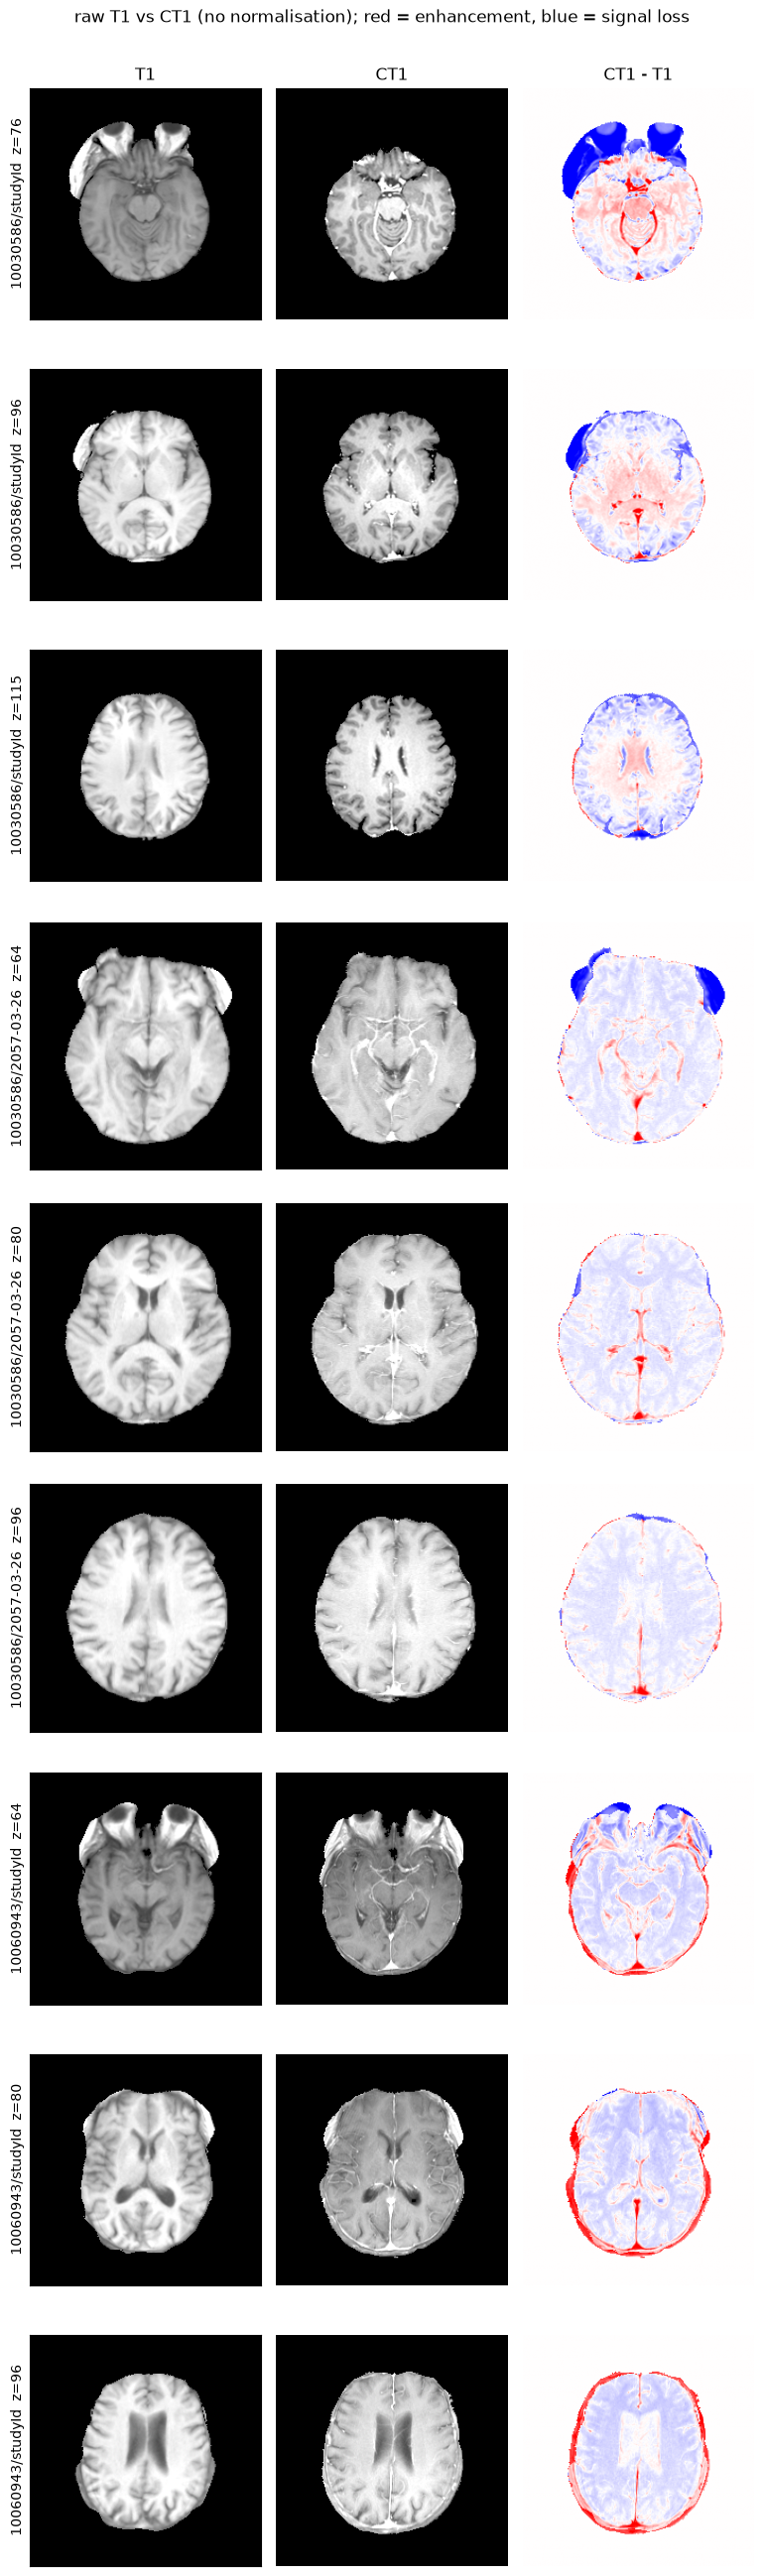

(<Figure size 780x2610 with 27 Axes>,
 array([[<Axes: title={'center': 'T1'}, ylabel='10030586/studyId  z=76'>,
         <Axes: title={'center': 'CT1'}>,
         <Axes: title={'center': 'CT1 - T1'}>],
        [<Axes: ylabel='10030586/studyId  z=96'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='10030586/studyId  z=115'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='10030586/2057-03-26  z=64'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='10030586/2057-03-26  z=80'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='10030586/2057-03-26  z=96'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='10060943/studyId  z=64'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='10060943/studyId  z=80'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='10060943/studyId  z=96'>, <Axes: >, <Axes: >]],
       dtype=object))

In [25]:
# --- raw T1 vs CT1, and their difference, across a few subjects and slices ---
# Needs section 6 (nib, full_path) and `cell`. RAW intensities, no normalisation.
from visualization import subplot_images

N_SUBJ = 3
FRACS  = (0.40, 0.50, 0.60)      # slice positions as a fraction of the z extent
PCT    = 99.0                    # percentile setting the symmetric difference window


def load_ras(path):
    """Volume reoriented to canonical RAS, plus its affine. No resampling."""
    img = nib.as_closest_canonical(nib.load(path))
    v = np.asanyarray(img.dataobj)
    while v.ndim > 3:
        v = v[..., 0]
    return v.astype(np.float32), img.affine


pool  = full_sess if full_sess else sorted(cell, key=lambda k: -len(cell[k]))
pairs = [k for k in pool if "T1" in cell[k] and "T1ce" in cell[k]][:N_SUBJ]

rows, labels, diffs = [], [], []
for k in pairs:
    t1,  a1 = load_ras(full_path(cell[k]["T1"][0]))
    ct1, a2 = load_ras(full_path(cell[k]["T1ce"][0]))
    if t1.shape != ct1.shape:
        print(f"  !! {k}: {t1.shape} vs {ct1.shape} -- not on a common grid, skipped")
        continue
    if not np.allclose(a1, a2, atol=1e-3):
        print(f"  ?? {k}: shapes agree but affines differ -- the subtraction is only "
              f"meaningful if these are actually co-registered")
    for f in FRACS:
        z = int(f * t1.shape[2])
        a, b = np.rot90(t1[:, :, z]), np.rot90(ct1[:, :, z])
        rows.append([a, b, b - a])
        labels.append(f"{k[0]}/{k[1]}  z={z}")
        diffs.append(b - a)

assert rows, "no session had T1 and CT1 on a common grid"
dlim = float(np.percentile(np.abs(np.concatenate([d.ravel() for d in diffs])), PCT))
print(f"{len(rows)} panels; difference window +/-{dlim:.0f} (p{PCT} of |CT1 - T1|)")

subplot_images(
    rows,
    col_titles=["T1", "CT1", "CT1 - T1"],
    row_labels=labels,
    cmap=["gray", "gray", "bwr"],
    vmin=[None, None, -dlim],          # gray columns auto-window from p; diff is fixed
    vmax=[None, None, +dlim],          # and SHARED across rows, so magnitudes compare
    p=(1, 99),
    share_window=False,                # T1 and CT1 differ in raw scale; per-panel stretch
    panel_size=(2.6, 2.9),
    suptitle="raw T1 vs CT1 (no normalisation); red = enhancement, blue = signal loss",
)

9 panels | raw window +/-1587 | med/MAD window +/-3.30 | percentile window +/-0.40
Percentile normalization: T1 / p99, CT1 / p97


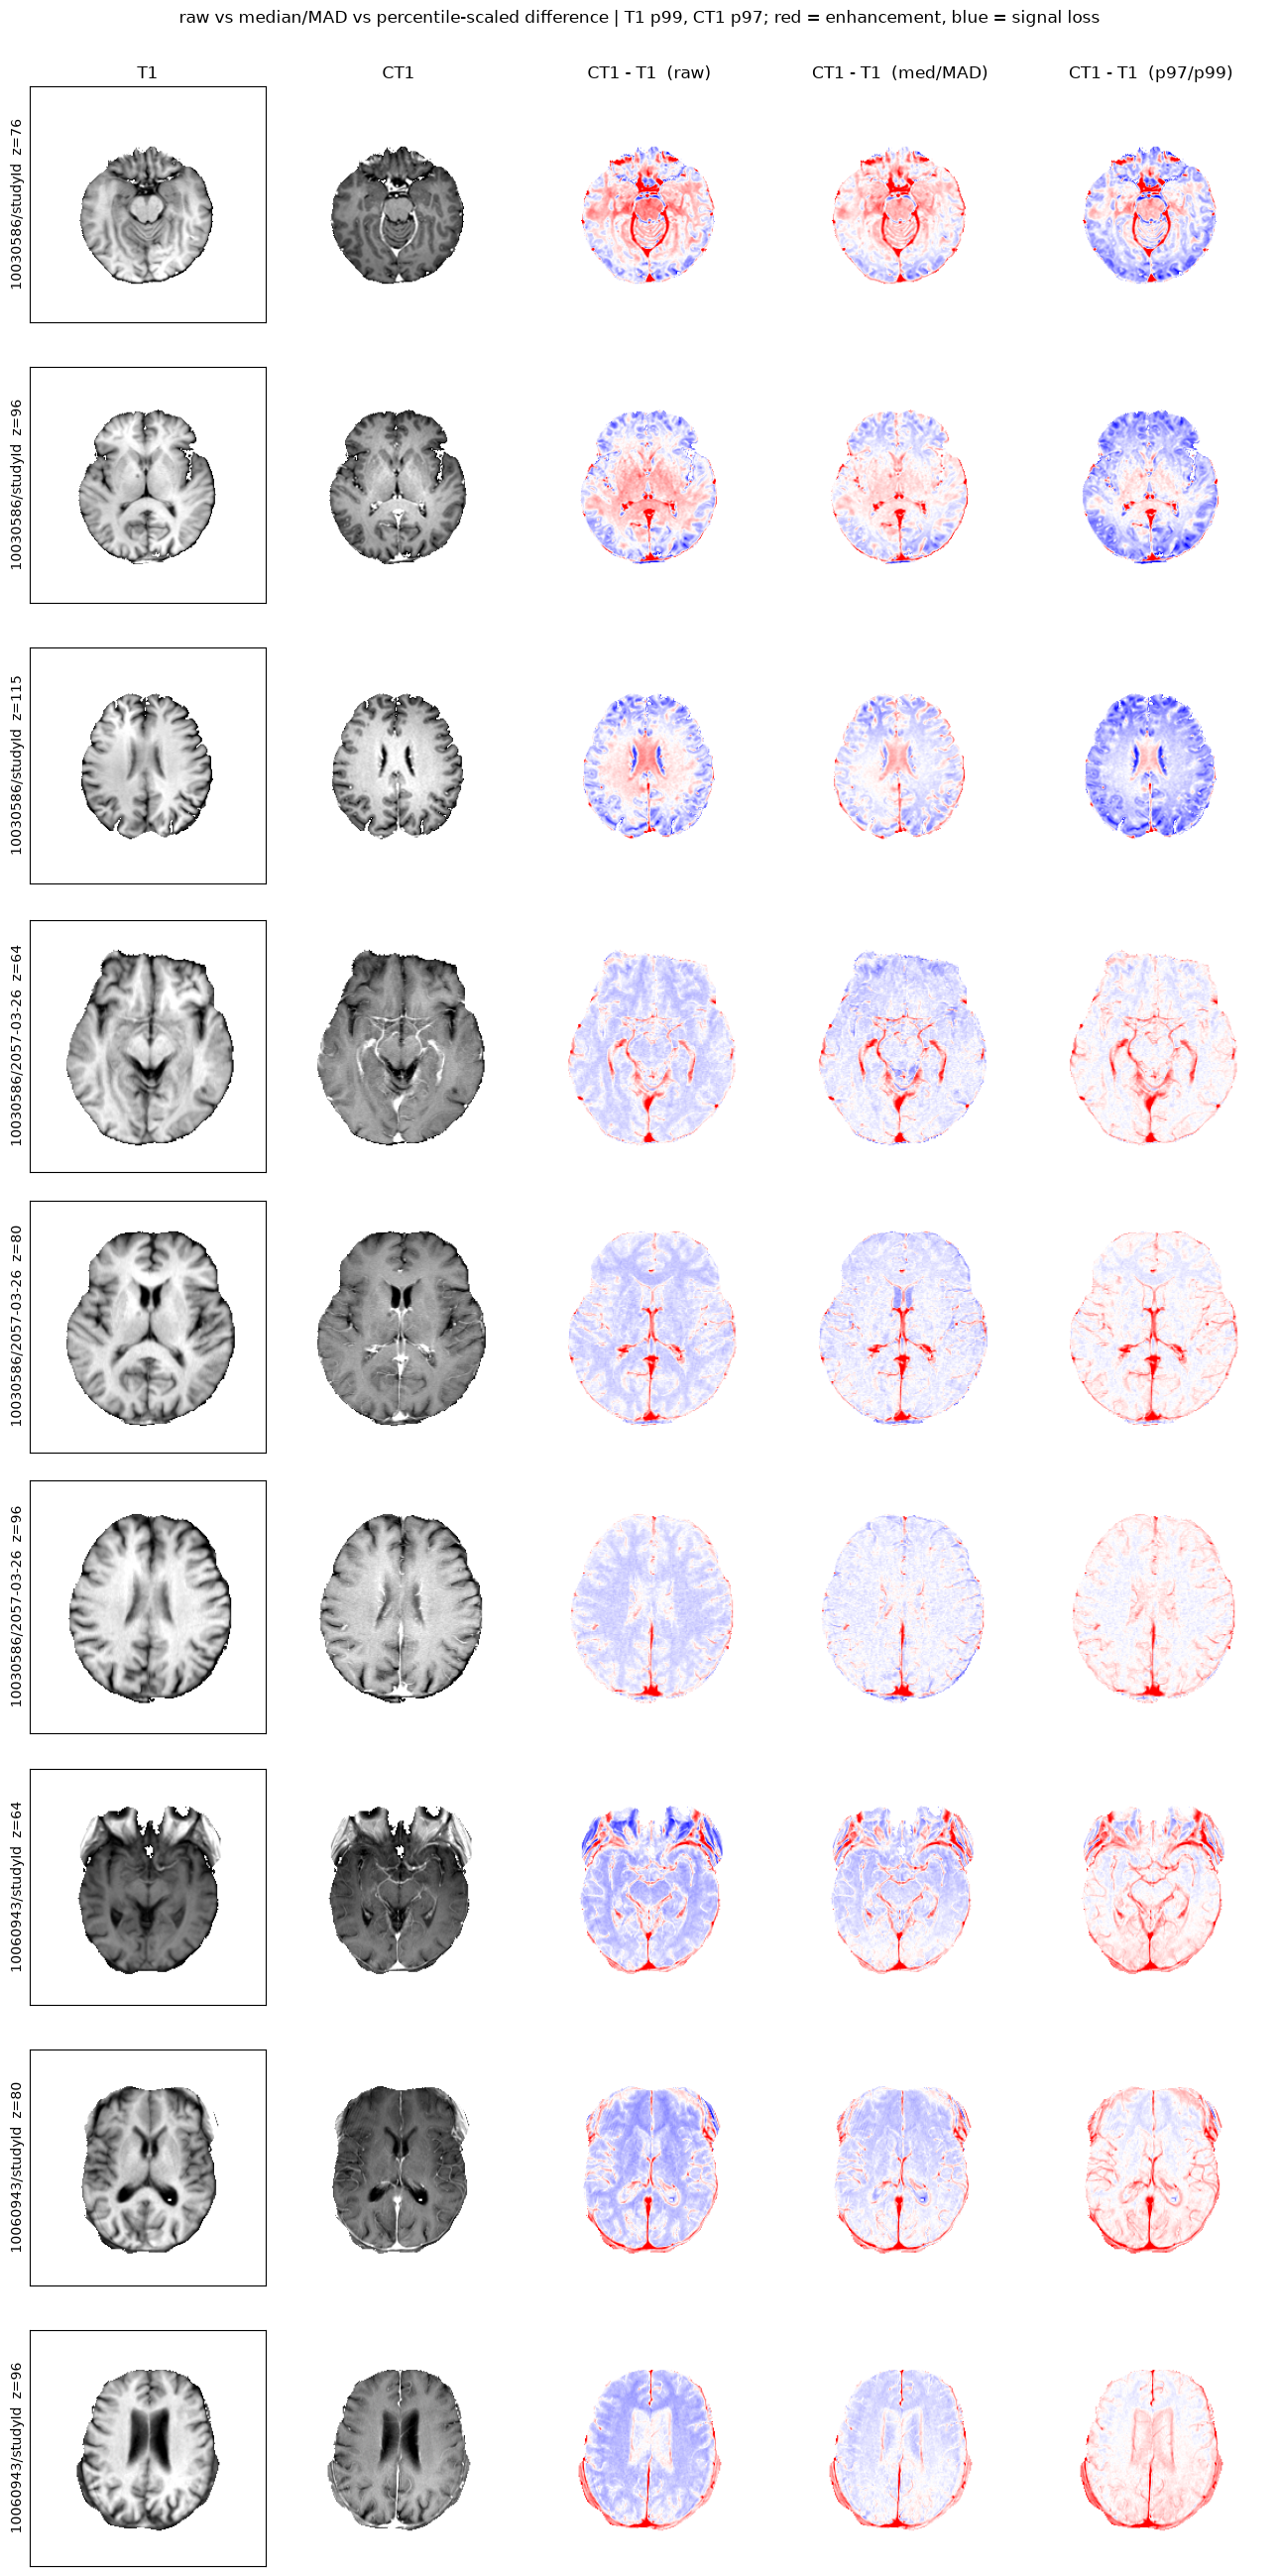


subject                     raw median  raw wash  m/M median  m/M wash  pct median  pct wash  MAD ratio
10030586/studyId                 -55.0      0.13       0.016      0.02      -0.084      0.84       1.69
10030586/2057-03-26             -119.0      0.60      -0.169      0.47       0.014      0.34       0.72
10060943/studyId                -181.0      0.53      -0.101      0.18       0.039      0.59       0.74

wash = |median| / MAD of the difference over the intersection of the T1 and CT1 supports.
Percentile normalization independently scales T1 and CT1 over this same intersection mask.
T1 is divided by its 99th percentile and CT1 by its 97th percentile.


In [33]:
# --- T1 vs CT1: raw difference vs median/MAD vs percentile-scaled difference ---
# Needs section 6 (nib, full_path) and `cell`.
from visualization import subplot_images

N_SUBJ  = 3
FRACS   = (0.40, 0.50, 0.60)     # slice positions as a fraction of the z extent

PCT     = 99.0                   # percentile for symmetric difference windows

# Percentile-based per-contrast normalization.
# Tune these independently.
T1_PCT  = 99.0
CT1_PCT = 97.0

_MAD_TO_STD = 1.4826


def load_ras(path):
    """Volume reoriented to canonical RAS, plus its affine. No resampling."""
    img = nib.as_closest_canonical(nib.load(path))
    v = np.asanyarray(img.dataobj)
    while v.ndim > 3:
        v = v[..., 0]
    return v.astype(np.float32), img.affine


def med_mad(v, m):
    """Robust centre/scale from masked voxels."""
    med = float(np.median(v[m]))
    mad = float(np.median(np.abs(v[m] - med))) * _MAD_TO_STD
    return med, max(mad, 1e-6)


def percentile_scale(v, m, pct):
    """Scale an image by a percentile computed over masked voxels."""
    scale = float(np.percentile(v[m], pct))
    return v / max(scale, 1e-6), scale


def wash(d, m):
    """|median| / MAD of a difference over the supplied mask."""
    md = float(np.median(d[m]))
    sp = float(np.median(np.abs(d[m] - md))) * _MAD_TO_STD
    return md, sp, abs(md) / max(sp, 1e-9)


pool  = full_sess if full_sess else sorted(cell, key=lambda k: -len(cell[k]))
pairs = [k for k in pool if "T1" in cell[k] and "T1ce" in cell[k]][:N_SUBJ]

rows, labels = [], []
d_raw, d_mm, d_pct = [], [], []
stats = []

for k in pairs:
    t1,  a1 = load_ras(full_path(cell[k]["T1"][0]))
    ct1, a2 = load_ras(full_path(cell[k]["T1ce"][0]))

    if t1.shape != ct1.shape:
        print(f"  !! {k}: {t1.shape} vs {ct1.shape} -- not on a common grid, skipped")
        continue

    if not np.allclose(a1, a2, atol=1e-3):
        print(
            f"  ?? {k}: shapes agree but affines differ -- the subtraction is only "
            f"meaningful if these are actually co-registered"
        )

    # ------------------------------------------------------------------
    # INTERSECTION of supports
    #
    # Only retain voxels that contain nonzero data in BOTH scans.
    # This removes anatomy that is present in T1 but absent from T1ce,
    # such as eyes/skull or other extra coverage.
    # ------------------------------------------------------------------
    support = (t1 != 0) & (ct1 != 0)

    if not np.any(support):
        print(f"  !! {k}: empty intersection support -- skipped")
        continue

    # ------------------------------------------------------------------
    # Median/MAD normalization
    # ------------------------------------------------------------------
    (m1, s1), (m2, s2) = med_mad(t1, support), med_mad(ct1, support)

    t1_mm  = (t1 - m1) / s1
    ct1_mm = (ct1 - m2) / s2

    # ------------------------------------------------------------------
    # Percentile normalization
    # ------------------------------------------------------------------
    t1_pct,  t1_scale  = percentile_scale(t1, support, T1_PCT)
    ct1_pct, ct1_scale = percentile_scale(ct1, support, CT1_PCT)

    # Differences
    raw_diff = ct1 - t1
    mm_diff  = ct1_mm - t1_mm
    pct_diff = ct1_pct - t1_pct

    stats.append(
        (
            k,
            wash(raw_diff, support),
            wash(mm_diff, support),
            wash(pct_diff, support),
            s2 / s1,
            t1_scale,
            ct1_scale,
        )
    )

    # ------------------------------------------------------------------
    # Slices
    # ------------------------------------------------------------------
    for f in FRACS:
        z = int(f * t1.shape[2])

        def masked_sl(v):
            x = np.rot90(v[:, :, z])
            m = np.rot90(support[:, :, z])
            return np.where(m, x, np.nan)

        rows.append(
            [
                masked_sl(t1),
                masked_sl(ct1),
                masked_sl(raw_diff),
                masked_sl(mm_diff),
                masked_sl(pct_diff),
            ]
        )

        labels.append(f"{k[0]}/{k[1]}  z={z}")

        d_raw.append(rows[-1][2])
        d_mm.append(rows[-1][3])
        d_pct.append(rows[-1][4])


assert rows, "no session had T1 and CT1 on a common grid"


# ----------------------------------------------------------------------
# Fixed symmetric windows for the difference maps
# ----------------------------------------------------------------------
def lim(ds):
    vals = np.concatenate(
        [np.abs(d[np.isfinite(d)]).ravel() for d in ds]
    )
    return float(np.percentile(vals, PCT))


lim_raw = lim(d_raw)
lim_mm  = lim(d_mm)
lim_pct = lim(d_pct)

print(
    f"{len(rows)} panels | "
    f"raw window +/-{lim_raw:.0f} | "
    f"med/MAD window +/-{lim_mm:.2f} | "
    f"percentile window +/-{lim_pct:.2f}"
)

print(
    f"Percentile normalization: "
    f"T1 / p{T1_PCT:g}, CT1 / p{CT1_PCT:g}"
)


# ----------------------------------------------------------------------
# Plot
# ----------------------------------------------------------------------
subplot_images(
    rows,
    col_titles=[
        "T1",
        "CT1",
        "CT1 - T1  (raw)",
        "CT1 - T1  (med/MAD)",
        f"CT1 - T1  (p{CT1_PCT:g}/p{T1_PCT:g})",
    ],
    row_labels=labels,
    cmap=["gray", "gray", "bwr", "bwr", "bwr"],
    vmin=[None, None, -lim_raw, -lim_mm, -lim_pct],
    vmax=[None, None, +lim_raw, +lim_mm, +lim_pct],
    p=(1, 99),
    share_window=False,
    panel_size=(2.6, 2.9),
    suptitle=(
        f"raw vs median/MAD vs percentile-scaled difference | "
        f"T1 p{T1_PCT:g}, CT1 p{CT1_PCT:g}; "
        f"red = enhancement, blue = signal loss"
    ),
)


# ----------------------------------------------------------------------
# Statistics
# ----------------------------------------------------------------------
print(
    f"\n{'subject':<26} "
    f"{'raw median':>11} {'raw wash':>9} "
    f"{'m/M median':>11} {'m/M wash':>9} "
    f"{'pct median':>11} {'pct wash':>9} "
    f"{'MAD ratio':>10}"
)

for k, raw, mm, pct, sr, t1_scale, ct1_scale in stats:
    r_md, _, r_w = raw
    n_md, _, n_w = mm
    p_md, _, p_w = pct

    print(
        f"{k[0]+'/'+k[1]:<26} "
        f"{r_md:>11.1f} {r_w:>9.2f} "
        f"{n_md:>11.3f} {n_w:>9.2f} "
        f"{p_md:>11.3f} {p_w:>9.2f} "
        f"{sr:>10.2f}"
    )

print(
    "\nwash = |median| / MAD of the difference over the intersection "
    "of the T1 and CT1 supports."
)
print(
    "Percentile normalization independently scales T1 and CT1 over "
    "this same intersection mask."
)
print(
    f"T1 is divided by its {T1_PCT:g}th percentile and "
    f"CT1 by its {CT1_PCT:g}th percentile."
)


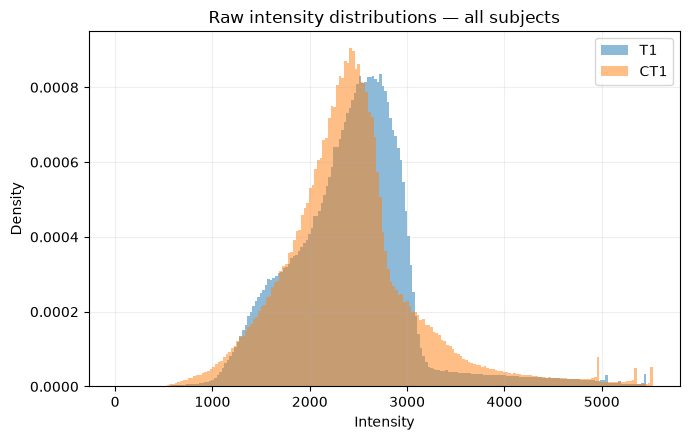

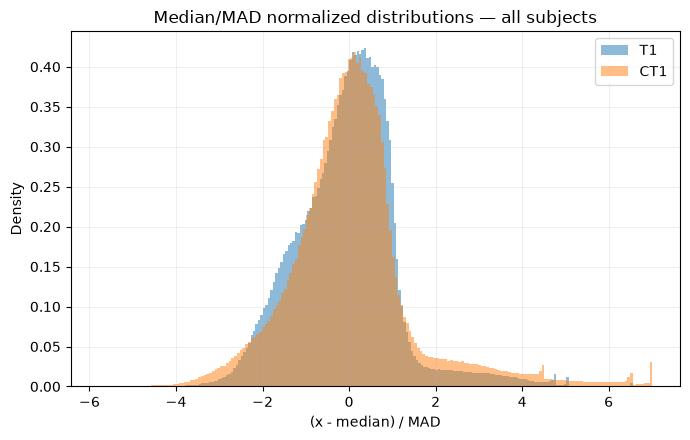

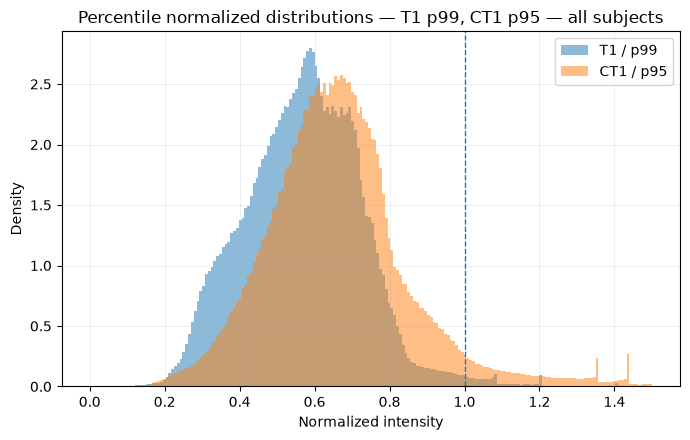


Percentile normalization scales:
10030586/studyId: T1 p99 = 3682.001, CT1 p95 = 3539.995
10030586/2057-03-26: T1 p99 = 4180.975, CT1 p95 = 3454.035
10060943/studyId: T1 p99 = 5050.294, CT1 p95 = 3939.983


In [31]:

# --- Histograms: raw vs median/MAD vs percentile normalization ---

import numpy as np
import matplotlib.pyplot as plt

# Histogram settings
HIST_BINS = 200
HIST_RANGE = (0, 1.5)     # useful for percentile-normalized images
DENSITY = True

# Plot one histogram per subject, with T1 and CT1 shown together.
# Set to None to pool all subjects instead.
HIST_SUBJ = None           # e.g. 0 for first subject, None for all subjects


def get_hist_data(v, mask):
    """Return finite, masked values."""
    x = v[mask]
    return x[np.isfinite(x)]


# Store distributions
hist_data = []

for k in pairs:
    t1,  a1 = load_ras(full_path(cell[k]["T1"][0]))
    ct1, a2 = load_ras(full_path(cell[k]["T1ce"][0]))

    if t1.shape != ct1.shape:
        continue

    # Same intersection mask used in the image comparison
    support = (t1 != 0) & (ct1 != 0)

    if not np.any(support):
        continue

    # -------------------------------
    # Raw
    # -------------------------------
    t1_raw = get_hist_data(t1, support)
    ct1_raw = get_hist_data(ct1, support)

    # -------------------------------
    # Median/MAD
    # -------------------------------
    m1, s1 = med_mad(t1, support)
    m2, s2 = med_mad(ct1, support)

    t1_mm = get_hist_data((t1 - m1) / s1, support)
    ct1_mm = get_hist_data((ct1 - m2) / s2, support)

    # -------------------------------
    # Percentile
    # -------------------------------
    t1_p, t1_scale = percentile_scale(t1, support, T1_PCT)
    ct1_p, ct1_scale = percentile_scale(ct1, support, CT1_PCT)

    t1_pct = get_hist_data(t1_p, support)
    ct1_pct = get_hist_data(ct1_p, support)

    hist_data.append(
        {
            "subject": k,
            "T1_raw": t1_raw,
            "CT1_raw": ct1_raw,
            "T1_mm": t1_mm,
            "CT1_mm": ct1_mm,
            "T1_pct": t1_pct,
            "CT1_pct": ct1_pct,
            "T1_scale": t1_scale,
            "CT1_scale": ct1_scale,
        }
    )


assert hist_data, "No subjects available for histogram plotting."


# ----------------------------------------------------------------------
# Select subjects or pool all subjects
# ----------------------------------------------------------------------
if HIST_SUBJ is not None:
    hd = hist_data[HIST_SUBJ]

    title_suffix = f"{hd['subject'][0]}/{hd['subject'][1]}"

    data = {
        key: hd[key]
        for key in [
            "T1_raw", "CT1_raw",
            "T1_mm", "CT1_mm",
            "T1_pct", "CT1_pct",
        ]
    }

else:
    title_suffix = "all subjects"

    data = {}
    for key in [
        "T1_raw", "CT1_raw",
        "T1_mm", "CT1_mm",
        "T1_pct", "CT1_pct",
    ]:
        data[key] = np.concatenate([h[key] for h in hist_data])


# ----------------------------------------------------------------------
# Raw intensity histograms
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(
    data["T1_raw"],
    bins=HIST_BINS,
    density=DENSITY,
    alpha=0.5,
    label="T1",
)

ax.hist(
    data["CT1_raw"],
    bins=HIST_BINS,
    density=DENSITY,
    alpha=0.5,
    label="CT1",
)

ax.set_xlabel("Intensity")
ax.set_ylabel("Density" if DENSITY else "Count")
ax.set_title(f"Raw intensity distributions — {title_suffix}")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# Median/MAD normalized histograms
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(
    data["T1_mm"],
    bins=HIST_BINS,
    density=DENSITY,
    alpha=0.5,
    label="T1",
)

ax.hist(
    data["CT1_mm"],
    bins=HIST_BINS,
    density=DENSITY,
    alpha=0.5,
    label="CT1",
)

ax.set_xlabel("(x - median) / MAD")
ax.set_ylabel("Density" if DENSITY else "Count")
ax.set_title(f"Median/MAD normalized distributions — {title_suffix}")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# Percentile normalized histograms
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(
    data["T1_pct"],
    bins=HIST_BINS,
    range=HIST_RANGE,
    density=DENSITY,
    alpha=0.5,
    label=f"T1 / p{T1_PCT:g}",
)

ax.hist(
    data["CT1_pct"],
    bins=HIST_BINS,
    range=HIST_RANGE,
    density=DENSITY,
    alpha=0.5,
    label=f"CT1 / p{CT1_PCT:g}",
)

ax.axvline(1.0, linestyle="--", linewidth=1)

ax.set_xlabel("Normalized intensity")
ax.set_ylabel("Density" if DENSITY else "Count")
ax.set_title(
    f"Percentile normalized distributions — "
    f"T1 p{T1_PCT:g}, CT1 p{CT1_PCT:g} — {title_suffix}"
)
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# Print the actual normalization scales
# ----------------------------------------------------------------------
print("\nPercentile normalization scales:")
for h in hist_data:
    k = h["subject"]
    print(
        f"{k[0]}/{k[1]}: "
        f"T1 p{T1_PCT:g} = {h['T1_scale']:.3f}, "
        f"CT1 p{CT1_PCT:g} = {h['CT1_scale']:.3f}"
    )
